In [167]:
import numpy as np
import ipywidgets as widgets
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import Image

class GridWorld:
    def __init__(self, size=5, reset_break=5, holes=None):
        self.size = size
        self.reset_break = reset_break
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        # self.holes = holes if holes else  [(1,1), (2,0), (2,3), (3,3), (4,2)]
        self.holes = holes if holes else  [(1,1), (3,0), (0,3), (3,4), (4,2)]

        self.episode = 0
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)} # up, down, left, right
        self.reset()

    def reset(self):
        self.agent_pos = [0, 0]
        self.done = False
        self.steps = 0
        self.total_reward = 0
        self.episode += 1
        return tuple(self.agent_pos)

    def step(self, action):
        if self.done:
            return tuple(self.agent_pos), 0, True, {}

        move = self.actions[action]
        new_pos = [self.agent_pos[0] + move[0], self.agent_pos[1] + move[1]]

        # stay in bounds
        if 0 <= new_pos[0] < self.size and 0 <= new_pos[1] < self.size:
            self.agent_pos = new_pos

        state = tuple(self.agent_pos)

        # check terminal conditions
        if state == self.goal:
            reward, done, info = 10, True, f"You reached the goal! Resetting in {self.reset_break} seconds."
        elif state in self.holes:
            reward, done, info = -10, True, f"You fell into a hole! Resetting in {self.reset_break} seconds."
        else:
            reward, done, info = -1, False, ""

        self.total_reward += reward
        self.done = done
        self.steps += 1

        msg = (f"Episode {self.episode} | Step {self.steps} | "
               f"Reward {reward:+} | Total Reward {self.total_reward:+}")
        if info:
            msg += " → " + info

        #return tuple(self.agent_pos), reward, done, {"msg": msg}
        return state, reward, done, {"msg": msg}

    def render_dot_grid(self):
        grid = np.full((self.size, self.size), ".")
        # Goal
        grid[self.size-1, self.size-1] = "G"
        # Holes
        for (r, c) in self.holes:
            grid[r, c] = "H"
        # Agent (show step number instead of "A")
        grid[self.agent_pos[0], self.agent_pos[1]] = str(self.steps)
        for row in grid:
            print(" ".join(row))

    def render(self, ax=None, title=""):
        """Draw grid with agent, holes, and goal."""
        grid = np.zeros((self.size, self.size))
        for h in self.holes:
            grid[h] = -1
        grid[self.goal] = 2
        #grid[self.agent_pos[0], self.agent_pos[1]] = 1

        cmap = colors.ListedColormap(["red", "blue", "black", "green"])
        bounds = [-2, -0.5, 0.5, 1.5, 2.5]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        if ax is None:
            fig, ax = plt.subplots()
        ax.imshow(grid, cmap=cmap, norm=norm)
        ax.text(self.agent_pos[1], self.agent_pos[0], str(self.steps),
                    ha="center", va="center",
                    color="white", fontsize=12, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        return ax

In [ ]:
def record_episode(env, policy, filename="episode.gif", max_steps=50, fps=1):
    frames = []
    fig, ax = plt.subplots()

    state = env.reset()
    done = False
    steps = 0
    while not done and steps < max_steps:
        ax.clear()
        env.render(ax=ax, title=f"Step {steps}, Total Reward {env.total_reward}")
        fig.canvas.draw()
        fig.canvas.flush_events()
        frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
        frame = np.asarray(fig.canvas.buffer_rgba()).copy()
        frames.append(frame)

        action = policy(state)
        state, reward, done, info = env.step(action)
        #print(action, state, reward, done)
        steps += 1

        if done:
            ax.clear()
            env.render(ax=ax, title=f"Step {steps}, Total Reward {env.total_reward}")
            fig.canvas.draw()
            fig.canvas.flush_events()
            frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
            frame = np.asarray(fig.canvas.buffer_rgba()).copy()
            frames.append(frame)

    plt.close(fig)

    import imageio
    len(frames)
    print("Total frames:", len(frames))
    imageio.mimsave(filename, frames, fps=fps)
    return filename

# **Q-Learning**

In [238]:
import numpy as np
import ipywidgets as widgets
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import Image


def Q_learning(env, gamma=0.99, epsilon=0.1, alpha=0.1):
  states = [(i, j) for i in range(env.size) for j in range(env.size)]
  actions = list(env.actions.keys())
  Q = np.zeros((25 , 4))

  for episode in range(1000):
    s = env.reset()
    done = False
    while not done:
      a = epsilon_greedy (Q , s , epsilon, 4 )
      state_id = (s[0] * 5) + s[1]
      s_next , r , done , _ = env.step( a )

      next_state_id = (s_next[0] * 5) + s_next[1]

      Q[state_id, a] = Q[state_id, a] + alpha * (r + gamma*np.max(Q[next_state_id]) - Q[state_id, a])
      s = s_next

  policy = {}
  for s in states:
      state_id = (s[0] * 5) + s[1]
      if s == env.goal or s in env.holes:
          continue
      best_a = np.argmax(Q[state_id])
      policy[s] = best_a
  return Q, policy


def epsilon_greedy(Q, state, epsilon, n_actions):
    """
    Choose action using epsilon-greedy policy
    """
    state_id = (state[0] * 5) + state[1]
    if np.random.rand() < epsilon:
        action = np.random.randint(0, n_actions)  # explore
    else:
        action = np.argmax(Q[state_id])  # exploit
        # return max(range(n_actions), key=lambda a: Q[(state, a)])
    return action

Total frames: 9


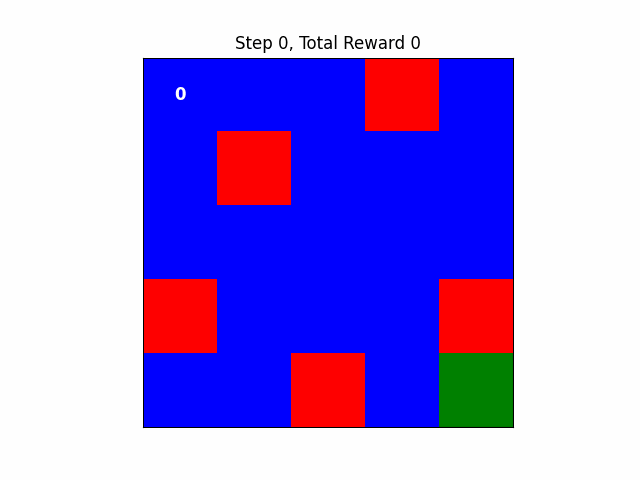

In [239]:
import random
env = GridWorld(size=5)
Q, q_policy = Q_learning(env)
q_policy_fn = lambda s: q_policy[s] if s in q_policy else random.choice(list(env.actions.keys()))
gif_file = record_episode(env, q_policy_fn, "q_learning.gif")
display(Image(filename=gif_file))

# **SARSA**

In [139]:
import numpy as np
import ipywidgets as widgets
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import Image


def SARSA(env, gamma=0.99, epsilon=0.1, alpha=0.1):
  states = [(i, j) for i in range(env.size) for j in range(env.size)]
  actions = list(env.actions.keys())
  Q = np.zeros((25 , 4))
  for episode in range(1000):
    s = env.reset()
    a = epsilon_greedy (Q , s , epsilon, 4 )
    done = False
    while not done:
      state_id = (s[0] * 5) + s[1]
      s_next , r , done , _ = env.step( a )
      a_next = epsilon_greedy (Q , s_next , epsilon, 4 )

      next_state_id = (s_next[0] * 5) + s_next[1]

      Q[state_id, a] = Q[state_id, a] + alpha * (r + gamma*Q[next_state_id, a_next] - Q[state_id, a])
      s , a = s_next , a_next

  policy = {}
  for s in states:
      state_id = (s[0] * 5) + s[1]
      if s == env.goal or s in env.holes:
          continue
      best_a = np.argmax(Q[state_id])
      policy[s] = best_a
  return Q, policy


def epsilon_greedy(Q, state, epsilon, n_actions):
    """
    Choose action using epsilon-greedy policy
    """
    state_id = (state[0] * 5) + state[1]
    if np.random.rand() < epsilon:
        action = np.random.randint(0, n_actions)  # explore
    else:
        action = np.argmax(Q[state_id])  # exploit
        # return max(range(n_actions), key=lambda a: Q[(state, a)])
    return action

Total frames: 9


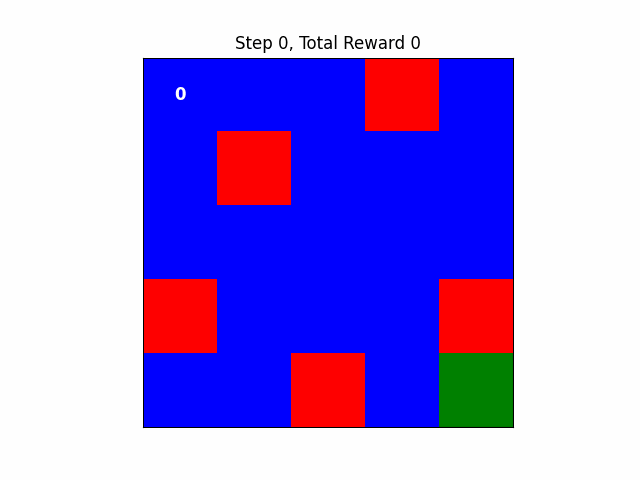

In [168]:
import random
env = GridWorld(size=5)
Q, sar_policy = SARSA(env)
sar_policy_fn = lambda s: sar_policy[s] if s in sar_policy else random.choice(list(env.actions.keys()))
gif_file = record_episode(env, sar_policy_fn, "sar_learning.gif")
display(Image(filename=gif_file))

# **Monte Carlo**

Total frames: 9


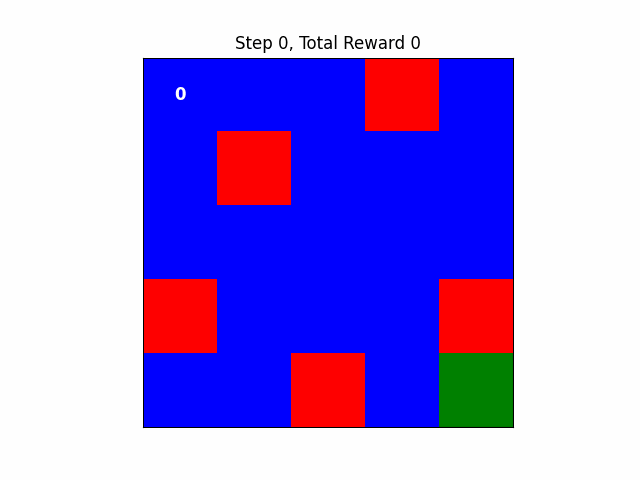

In [229]:
import numpy as np

def select_action2(Q, state, epsilon, n_actions):
    """
    Choose action using epsilon-greedy policy
    """
    # state_id = (state[0] * env.size) + state[1]
    if np.random.rand() < epsilon:
        action = np.random.randint(0, n_actions)  # explore
    else:
        action = np.argmax(Q[state])  # exploit
        # action = max(range(n_actions), key=lambda a: Q[(state, a)])
    return action


def monte_Carlo2(env, n_episodes=1500, ep_length = 50, alpha=0.1, gamma=0.9, epsilon=0.1):
    states = [(i, j) for i in range(env.size) for j in range(env.size)]
    actions = list(env.actions.keys())
    n_actions = len(env.actions)
    Q = {}
    size = 5
    n_actions = 4

    for i in range(size):
        for j in range(size):
            Q[(i, j)] = np.zeros(n_actions)

    for episode in range(n_episodes):
        stepsTaken = 0

      # 1: Generate a full episode
        s = env.reset()
        s_ep = []
        a_ep = []
        r_ep = []
        done = False

        for x in range(ep_length):
            # Using your epsilon_greedy helper
            a = select_action2(Q, s, epsilon, 4)

            s_next, r, done, _ = env.step(a)

            # Store the experience
            s_ep.append(s)
            a_ep.append(a)
            r_ep.append(r)

            if done or stepsTaken >= ep_length:
                break
            s = s_next
            stepsTaken = stepsTaken + 1


        g = 0.0
        for t in reversed(range(len(s_ep))):
            s = s_ep[t]
            a = a_ep[t]
            g = r_ep[t] + gamma * g

            Q[s][a] = Q[s][a] + alpha * (g - Q[s][a])

    policy = {}
    for s in states:
      # state_id = (s[0] * env.size) + s[1]
      if s == env.goal or s in env.holes:
          continue
      best_a = np.argmax(Q[s])
      policy[s] = best_a
    return Q, policy


import random
env = GridWorld(size=5)
Q, monte_carlo_policy = monte_Carlo2(env)
monte_carlo_policy_fn = lambda s: monte_carlo_policy[s] if s in monte_carlo_policy else random.choice(list(env.actions.keys()))
gif_file2 = record_episode(env, monte_carlo_policy_fn, "monte_carlo_learning.gif")
display(Image(filename=gif_file2))

# **Random Agent**

Total frames: 4


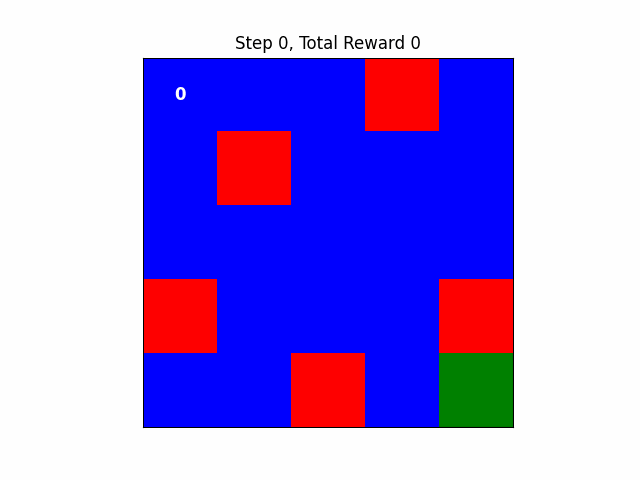

In [237]:
# import random
# def random_policy(state):
#     return random.choice(list(env.actions.keys()))

# # Run one random episode
# state = env.reset()
# done = False
# while not done:
#     action = random_policy(state)
#     state, reward, done, info = env.step(action)
#     # env.render(title=f"Random move: {action}, Reward={reward}")
#     plt.show()
# print("Total reward:", env.total_reward)

import random
env = GridWorld(size=5)
# Q, monte_carlo_policy = monte_Carlo2(env)
# monte_carlo_policy_fn = lambda s: monte_carlo_policy[s] if s in monte_carlo_policy else random.choice(list(env.actions.keys()))
random_policy_fn = lambda s: random.choice(list(env.actions.keys()))
gif_file2 = record_episode(env, random_policy_fn, "random_learning.gif")
display(Image(filename=gif_file2))


# record(env, random_policy_fn, vi_policy_fn)